In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from pathlib import Path
import pandas as pd
import json
from src.config import CHECKPOINT_DIR
from pathlib import Path
import matplotlib.pyplot as plt



In [3]:
grid_search_results_path = CHECKPOINT_DIR / "CNN_LSTM_V2" / "grid_search_1" / "grid_search_results.csv"

df = pd.read_csv(grid_search_results_path)
df.head()

,run_name,num_frames,augment,batch_size,learning_rate,min_lr,factor,scheduler_patience,epochs,early_stopping_patience,...,dropout,freeze_cnn,partial_freeze_cnn,cnn_cutoff,best_val_acc,final_train_acc,final_val_acc,final_train_loss,final_val_loss,epochs_ran
0,run_1,32,True,4,0.0001,0.00001,0.5,5,75,15,...,0.30,True,False,16,0.7500,0.805000,0.7300,0.423932,0.594919,35
1,run_2,32,True,4,0.0001,0.00001,0.5,5,75,15,...,0.35,True,False,16,0.7500,0.785625,0.7400,0.452386,0.533487,20
2,run_3,32,True,4,0.0001,0.00001,0.5,5,75,15,...,0.30,True,False,16,0.7425,0.781250,0.6975,0.458319,0.567969,18
3,run_4,32,True,4,0.0001,0.00001,0.5,5,75,15,...,0.35,True,False,16,0.7475,0.800000,0.7050,0.419943,0.551683,20
4,run_5,32,True,4,0.0001,0.00001,0.5,5,75,15,...,0.30,True,False,19,0.7600,0.821875,0.7200,0.383705,0.553952,32


In [4]:
def make_title(run_name, config, display_params):
    title = [run_name]

    for param in display_params:
        if param in config:
            title.append(f"{param}={config[param]}")

    return " | ".join(title)

def get_results(results_path):

    checkpoint_path = results_path / "best_model.pt"
    history_path = results_path / "history.csv"
    summary_path = results_path / "summary.csv"
    config_path = results_path / "config.json"

    required_files = [
        checkpoint_path,
        history_path,
        summary_path,
        config_path,
    ]

    if not all(path.exists() for path in required_files):
        return None

    checkpoint = torch.load(
        checkpoint_path,
        map_location=torch.device("cpu")
    )

    history = pd.read_csv(history_path)
    summary = pd.read_csv(summary_path)

    with config_path.open("r", encoding="utf-8") as f:
        config = json.load(f)

    return checkpoint, history, summary, config

def plot_grid_search_results(experiment_root, display_params):

    run_dirs = sorted([d for d in experiment_root.iterdir() if d.is_dir()])
    
    for run_dir in run_dirs:

        results = get_results(run_dir)

        if results is None:
            print(f"Skipping incomplete run: {run_dir.name}")
            continue

        checkpoint, history, summary, config = results

        epochs = range(1, len(history["train_loss"]) + 1)

        title = make_title(run_dir.name, config, display_params)

        plt.figure(figsize=(12, 5))

        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, history["train_loss"], label="Train Loss")
        plt.plot(epochs, history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss")
        plt.legend()
        plt.grid(True)

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history["train_acc"], label="Train Acc")
        plt.plot(epochs, history["val_acc"], label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

        print(summary['best_val_acc'][0])
        print(config)

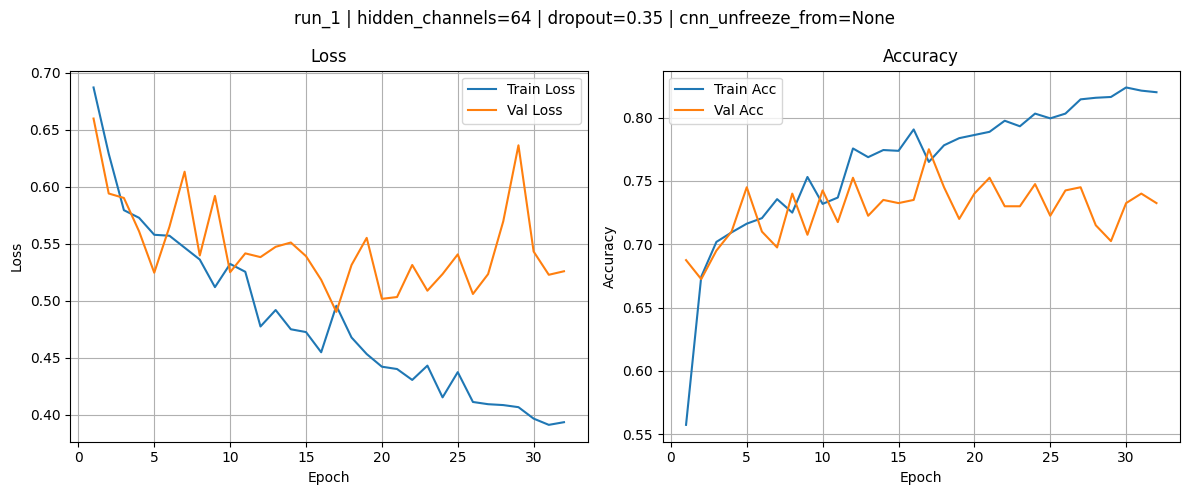

0.775
{'num_frames': 32, 'augment': True, 'batch_size': 4, 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-05, 'min_lr': 1e-05, 'factor': 0.5, 'use_differential_lr': False, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'seed': 42, 'hidden_channels': 64, 'reduced_channels': 64, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': None}


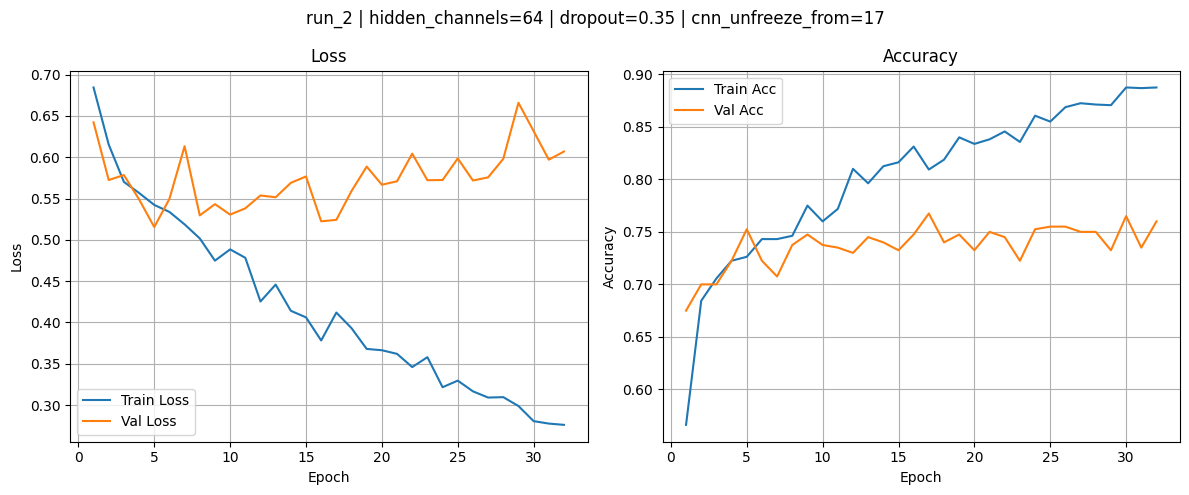

0.7675
{'num_frames': 32, 'augment': True, 'batch_size': 4, 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-05, 'min_lr': 1e-05, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'seed': 42, 'hidden_channels': 64, 'reduced_channels': 64, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 17}


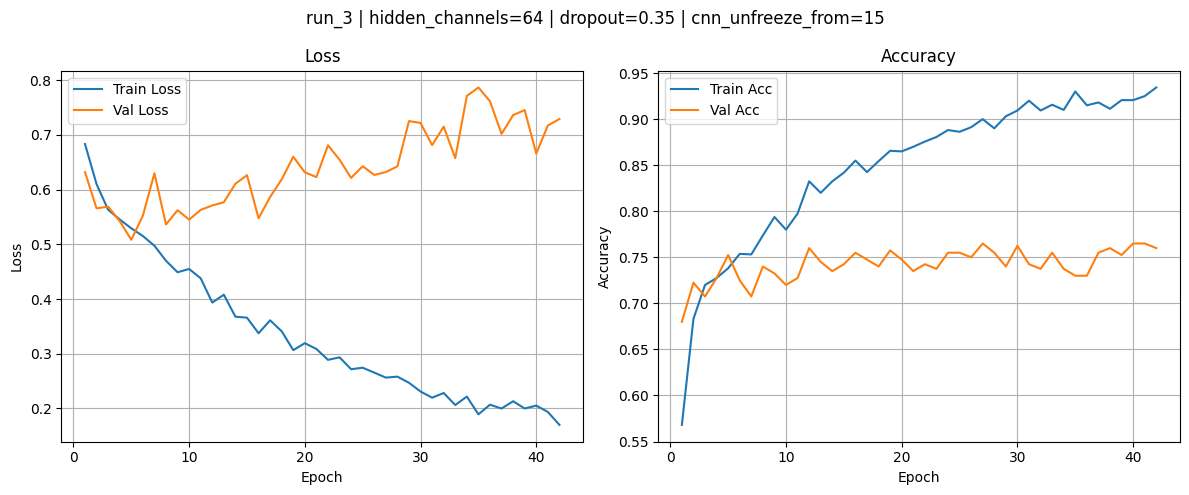

0.765
{'num_frames': 32, 'augment': True, 'batch_size': 4, 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-05, 'min_lr': 1e-05, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'seed': 42, 'hidden_channels': 64, 'reduced_channels': 64, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 15}


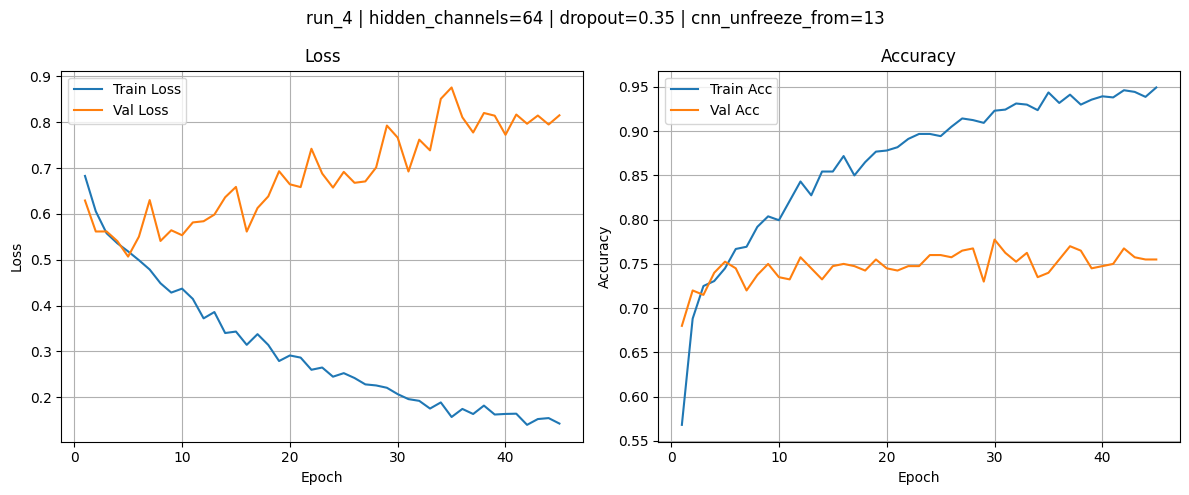

0.7775
{'num_frames': 32, 'augment': True, 'batch_size': 4, 'learning_rate': 0.0001, 'cnn_learning_rate': 1e-05, 'min_lr': 1e-05, 'factor': 0.5, 'use_differential_lr': True, 'scheduler_patience': 5, 'epochs': 75, 'early_stopping_patience': 15, 'seed': 42, 'hidden_channels': 64, 'reduced_channels': 64, 'dropout': 0.35, 'cnn_cutoff': 19, 'cnn_unfreeze_from': 13}


In [6]:
experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V2" / "grid_search_2_unfreeze_cnn"
display_params = ["hidden_channels", "dropout", "cnn_unfreeze_from"]

plot_grid_search_results(experiment_root, display_params)